# Analyse des données League of Legends

**Problématique** : Analyser et trouver quel est le meilleur champion et quels sont les rôles et les positions les plus représentés

#### Initialisation des librairies

In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

path = "data/"

#### Initialisation des Datasets

##### Champion Dataset

In [78]:
champs = pd.read_csv(path + "champs.csv")

##### Participants Dataset

In [79]:
participants = pd.read_csv(path + "participants.csv")

##### Matches Dataset

In [80]:
matches = pd.read_csv(path + "matches.csv")

##### Stat1 Dataset

In [81]:
stats1 = pd.read_csv(path + "stats1.csv")

##### Stat2 Dataset

In [82]:
stats2 = pd.read_csv(path + "stats2.csv", na_values=[r"\N"], dtype={"wardsbought": "Int64"})

##### Team Bans Dataframe

In [83]:
teambans = pd.read_csv(path + "teambans.csv")

##### Team Stats Dataframe

In [84]:
teamstats = pd.read_csv(path + "teamstats.csv")

#### Tests et analyse

In [85]:
# python
# quick diagnostics
print(participants.shape)
print(participants.columns.tolist())
print(participants['position'].dtype, participants['role'].dtype)
print(participants['position'].isna().sum(), participants['role'].isna().sum())
print(participants[['position', 'role']].head())

# vectorized fix (fast)
mask_bot = participants['position'] == "BOT"
participants.loc[mask_bot & (participants['role'] == 'DUO_SUPPORT'), 'position'] = "SUPP"
participants.loc[mask_bot & (participants['role'] != 'DUO_SUPPORT'), 'position'] = "ADC"

# verify
participants.loc[:, ["position", "role"]].head()

print(participants['championid'].dtype, champs['id'].dtype)


(1834520, 8)
['id', 'matchid', 'player', 'championid', 'ss1', 'ss2', 'role', 'position']
str str
0 0
  position         role
0   JUNGLE         NONE
1      BOT  DUO_SUPPORT
2      BOT    DUO_CARRY
3      TOP         SOLO
4      MID         SOLO
int64 int64


In [104]:
participants["teamid"] = participants.player.apply(lambda x: 100 if x <= 5 else 200)

keep_cols_stats = ["id", "win", "kills"]
keep_cols_participants = ['id', 'champion_name', 'player', 'win', 'kills', 'deaths', 'assists', 'totdmgdealt', 'ss1',
                          'ss2',
                          'position']

stats = pd.concat([stats1, stats2])

train_data = pd.merge(participants, teamstats.drop(["firstblood"], axis=1), on=["matchid", "teamid"])
train_data = pd.merge(participants, stats, how='left', on=['id'], suffixes=('', '_y'))

champs_info = champs[['id', 'name']].rename(columns={'name': 'champion_name'})

train_data = pd.merge(train_data, champs_info, left_on='championid', right_on='id', how='left', suffixes=('', '_champ'))

train_data = train_data[keep_cols_participants]
only_winners = train_data[train_data["win"] == 1]

only_winners

,id,champion_name,player,win,kills,deaths,assists,totdmgdealt,ss1,ss2,position
5,14,Skarner,6,1.0,3.0,3.0,9.0,148791.0,11,4,JUNGLE
6,15,Galio,7,1.0,4.0,5.0,11.0,130692.0,4,12,TOP
7,16,Ahri,8,1.0,13.0,4.0,8.0,145731.0,14,4,MID
8,17,Jinx,9,1.0,15.0,3.0,9.0,182680.0,7,4,BOT
9,18,VelKoz,10,1.0,4.0,5.0,19.0,85785.0,14,4,BOT
...,...,...,...,...,...,...,...,...,...,...,...
1834510,1865595,Twisted Fate,1,1.0,3.0,14.0,7.0,166561.0,4,12,MID
1834511,1865596,Tristana,2,1.0,10.0,6.0,11.0,220556.0,7,4,BOT
1834512,1865597,Xin Zhao,3,1.0,22.0,9.0,15.0,285357.0,4,11,JUNGLE
1834513,1865598,Malphite,4,1.0,7.0,4.0,22.0,125706.0,12,4,TOP


###  Quel est le role avec le plus de victoires ?

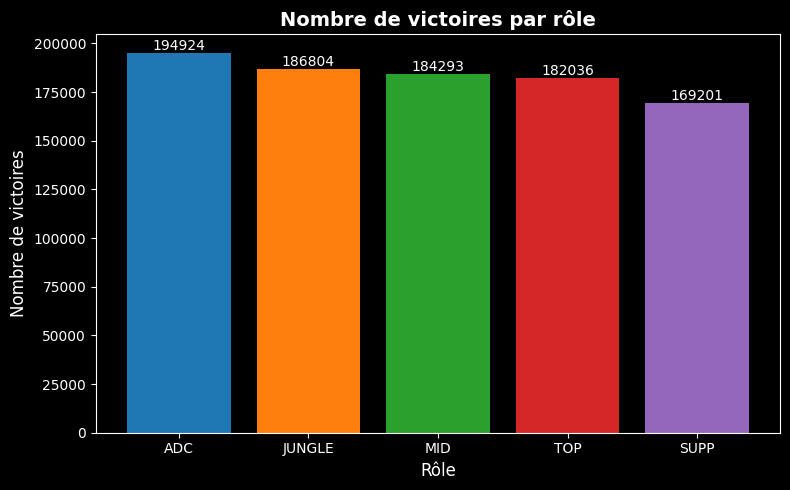

In [106]:
# Graphique : nombre de victoires par role
mask_bot = participants['position'] == "BOT"
participants.loc[mask_bot & (participants['role'] == 'DUO_SUPPORT'), 'position'] = "SUPP"
participants.loc[mask_bot & (participants['role'] != 'DUO_SUPPORT'), 'position'] = "ADC"

stats = pd.concat([stats1, stats2])[["id", "win"]]

df = pd.merge(participants[["id", "position"]], stats, on="id")

wins_by_position = df[df["win"] == 1].groupby("position").size().sort_values(ascending=False)

# Graphique
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(wins_by_position.index, wins_by_position.values, color=colors[:len(wins_by_position)])

ax.set_title("Nombre de victoires par rôle", fontsize=14, fontweight="bold")
ax.set_xlabel("Rôle", fontsize=12)
ax.set_ylabel("Nombre de victoires", fontsize=12)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

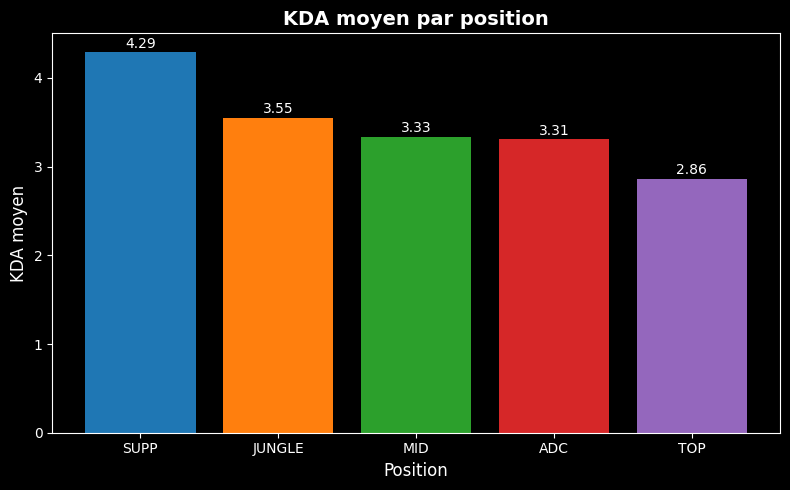

In [107]:
# Graphique : KDA moyen par position
mask_bot = participants['position'] == "BOT"
participants.loc[mask_bot & (participants['role'] == 'DUO_SUPPORT'), 'position'] = "SUPP"
participants.loc[mask_bot & (participants['role'] != 'DUO_SUPPORT'), 'position'] = "ADC"

stats = pd.concat([stats1, stats2])[["id", "kills", "deaths", "assists"]]
df = pd.merge(participants[["id", "position"]], stats, on="id")

# Calcul du KDA moyen par position
df["kda"] = (df["kills"] + df["assists"]) / df["deaths"].replace(0, 1)
kda_by_position = df.groupby("position")["kda"].mean().sort_values(ascending=False)

# Graphique
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(kda_by_position.index, kda_by_position.values, color=colors[:len(kda_by_position)])

ax.set_title("KDA moyen par position", fontsize=14, fontweight="bold")
ax.set_xlabel("Position", fontsize=12)
ax.set_ylabel("KDA moyen", fontsize=12)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Quel est le champion avec le plus de victoires ?

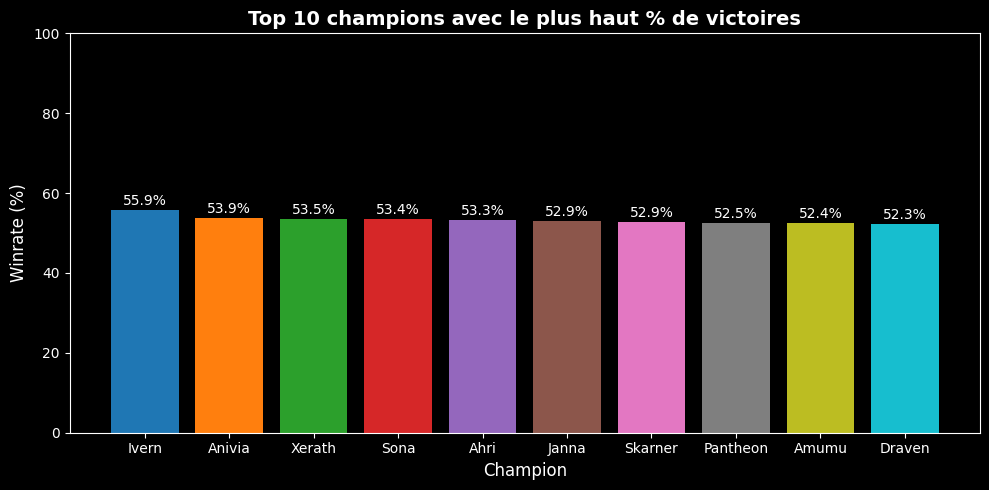

In [113]:
#graphique : nombre de victoires par champion (10 premiers)
stats = pd.concat([stats1, stats2])[["id", "win"]]
df = pd.merge(participants[["id", "championid"]], stats, on="id")

champ_stats = df.groupby("championid")["win"].agg(["sum", "count"])
champ_stats["winrate"] = (champ_stats["sum"] / champ_stats["count"]) * 100

top10 = champ_stats.nlargest(10, "winrate")

top10 = top10.reset_index()
top10 = pd.merge(top10, champs, left_on="championid", right_on="id")
top10 = top10.sort_values("winrate", ascending=False)

# Graphique
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top10["name"], top10["winrate"], color=colors)

ax.set_title("Top 10 champions avec le plus haut % de victoires", fontsize=14, fontweight="bold")
ax.set_xlabel("Champion", fontsize=12)
ax.set_ylabel("Winrate (%)", fontsize=12)
ax.set_ylim(0, 100)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Quel est le champion avec le meilleur nombre d'éliminations en moyenne ?

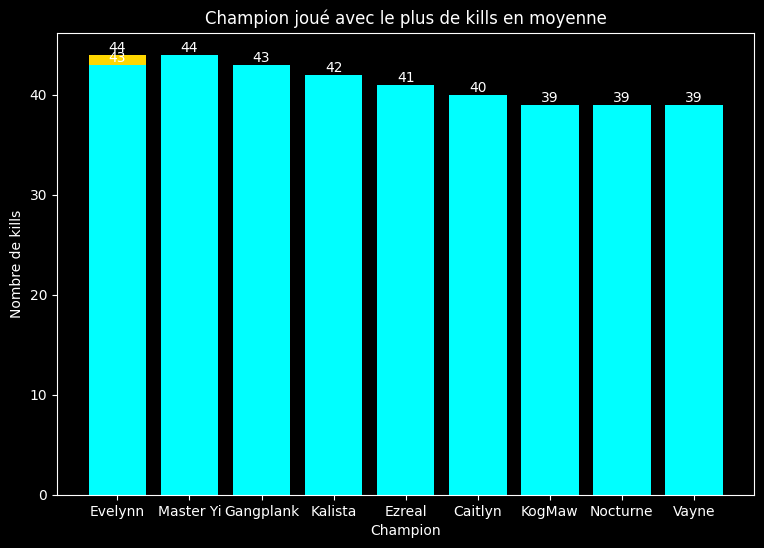

In [156]:
plt.figure(figsize=(9, 6))

selectedKills = only_winners.groupby("champion_name").agg(
    {"kills": "mean", "deaths": "mean", "assists": "mean"}).reset_index()
selectedKills = only_winners.sort_values(by="kills", ascending=False).head(10)

plt.bar_label(plt.bar(selectedKills["champion_name"], selectedKills["kills"],
                      color=['gold' if i == 0 else 'cyan' for i in range(len(selectedKills))]))

plt.title("Champion joué avec le plus de kills en moyenne")
plt.xlabel("Champion")
plt.ylabel("Nombre de kills")
plt.show()

### Quel est le champion avec le meilleur KDA (éliminations / morts / assitances) en moyenne ?

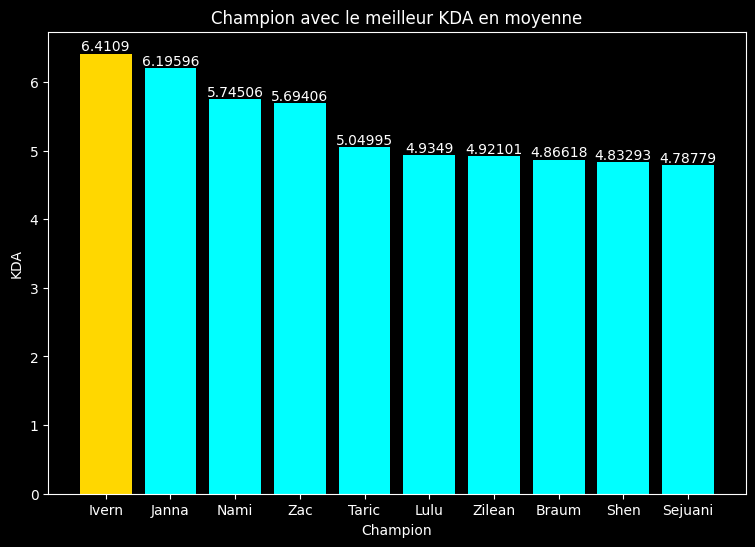

In [150]:
plt.figure(figsize=(9, 6))
selectedKDA = only_winners.groupby("champion_name").agg(
    {"kills": "mean", "deaths": "mean", "assists": "mean"}).reset_index()
selectedKDA["KDA"] = (selectedKDA["kills"] + selectedKDA["assists"]) / selectedKDA["deaths"].replace(0, 1)

selectedKDA = selectedKDA.sort_values(by="KDA", ascending=False).head(10)
plt.bar_label(plt.bar(selectedKDA["champion_name"], selectedKDA["KDA"],
                      color=['gold' if i == 0 else 'cyan' for i in range(len(selectedKDA))]))
plt.title("Champion avec le meilleur KDA en moyenne")
plt.xlabel("Champion")
plt.ylabel("KDA")
plt.show()

### Quel est le champion avec le plus de dégâts infligés en moyenne ?

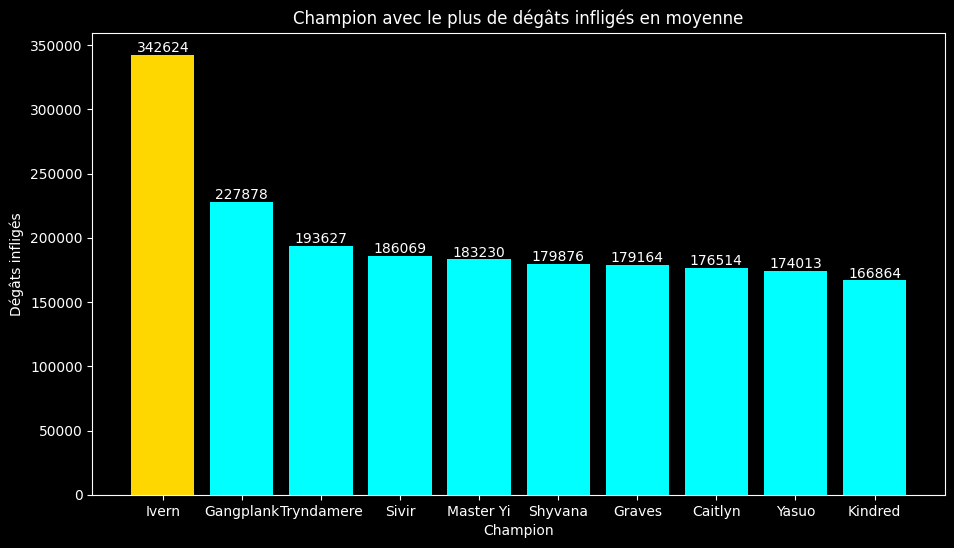

In [154]:
plt.figure(figsize=(11, 6))
selectedTotDmg = only_winners.groupby("champion_name").agg(
    {"totdmgdealt": "mean"}).reset_index()
selectedTotDmg = selectedTotDmg.sort_values(by="totdmgdealt", ascending=False).head(10)
plt.bar_label(plt.bar(selectedTotDmg["champion_name"], selectedTotDmg["totdmgdealt"],
                      color=['gold' if i == 0 else 'cyan' for i in range(len(selectedTotDmg))]))
plt.title("Champion avec le plus de dégâts infligés en moyenne")
plt.xlabel("Champion")
plt.ylabel("Dégâts infligés")
plt.show()

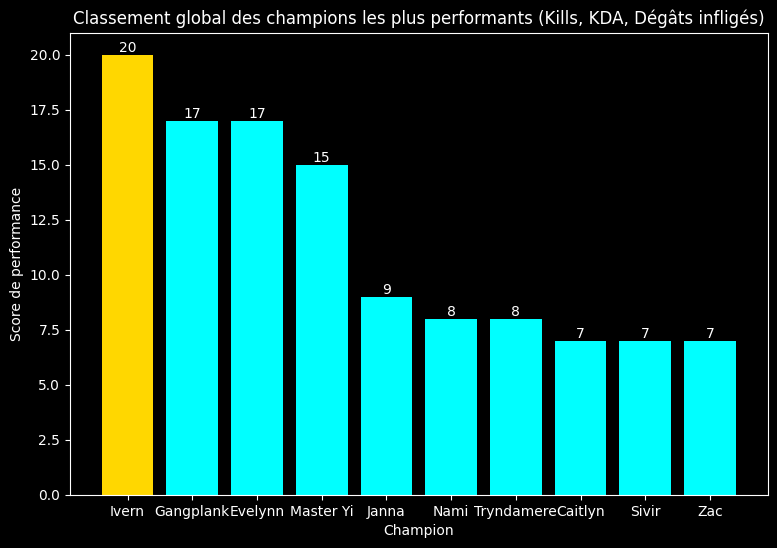

In [155]:
plt.figure(figsize=(9, 6))

all_selected = [selectedKills["champion_name"].tolist(), selectedKDA["champion_name"].tolist(),
                selectedTotDmg["champion_name"].tolist()]

best_overall = {
    value: 0 for value in
    only_winners["champion_name"].unique()
}

for selected in all_selected:
    for champion_pos in range(len(selected)):
        best_overall[selected[champion_pos]] += (10 - champion_pos)

best_overall = sorted(best_overall.items(), key=lambda x: x[1], reverse=True)

plt.bar_label(plt.bar([champ[0] for champ in best_overall[:10]], [champ[1] for champ in best_overall[:10]],
                      color=['gold' if i == 0 else 'cyan' for i in range(10)]))
plt.title("Classement global des champions les plus performants (Kills, KDA, Dégâts infligés)")
plt.xlabel("Champion")
plt.ylabel("Score de performance")
plt.show()